# Descarga y procesamiento de Dataset

El dataset se puede descargar desde https://zenodo.org/records/8037239, aqui obtenemos la base de datos de `neutron.csv` y `gamma.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
neutron = pd.read_csv('dataset/neutron.csv')
gamma = pd.read_csv('dataset/gamma.csv')

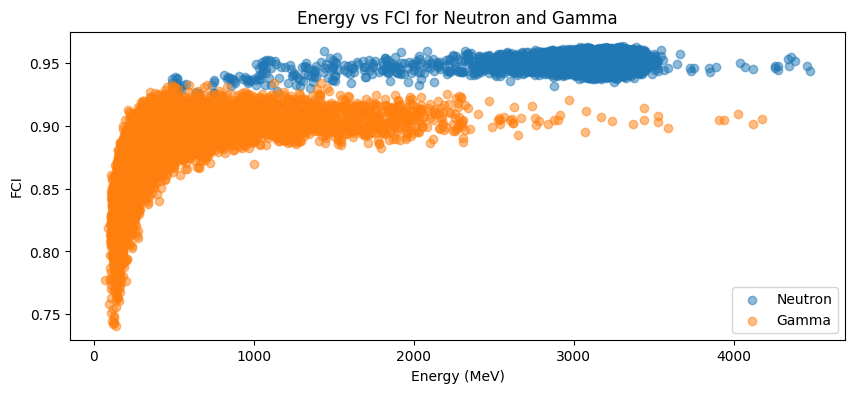

In [3]:
plt.figure(figsize=(10, 4))
plt.scatter(neutron['Energy'], neutron['FCI'], label='Neutron', alpha=0.5)
plt.scatter(gamma['Energy'], gamma['FCI'], label='Gamma', alpha=0.5)
plt.xlabel('Energy (MeV)')
plt.ylabel('FCI')
plt.title('Energy vs FCI for Neutron and Gamma')
plt.legend()

Gamma dataset shape:  (10913, 3004)
Neutron dataset shape:  (27696, 3004)


C:\Users\fabio\AppData\Local\Temp\ipykernel_16336\2166165845.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


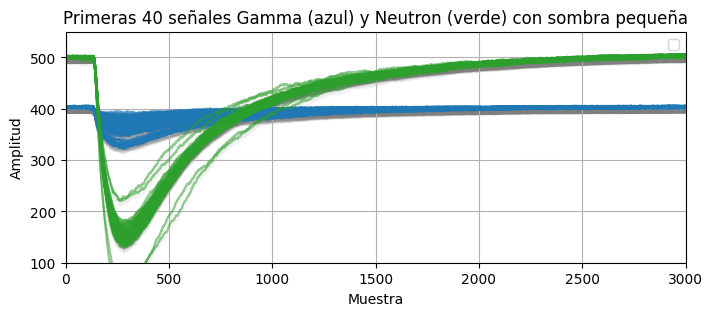

In [4]:
# Explore datasets and plot some signals
print("Gamma dataset shape: ", gamma.shape)
print("Neutron dataset shape: ", neutron.shape)
gamma.head()
neutron.head()

plt.figure(figsize=(8, 3))

# Graficar 40 señales gamma en azul con sombra pequeña debajo de la línea
for i in range(5000,5100):
    y = gamma.iloc[i, :-4]
    x = range(len(y))
    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

# Graficar 40 señales neutron en verde con sombra pequeña debajo de la línea
for i in range(5000,5100):
    y = neutron.iloc[i, :-4]
    x = range(len(y))
    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.title("Primeras 40 señales Gamma (azul) y Neutron (verde) con sombra pequeña")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.xlim(0, 3000)
plt.ylim(100, 550)
plt.legend()
plt.grid()
plt.show()

# tomar solo 160 datos de los 3000

In [5]:
indices = np.linspace(100, 2500 - 1, 161, dtype=int)
newNeutron = neutron.iloc[:, indices].values
newGamma = gamma.iloc[:, indices].values

Gamma dataset shape:  (10913, 161)
Neutron dataset shape:  (27696, 161)


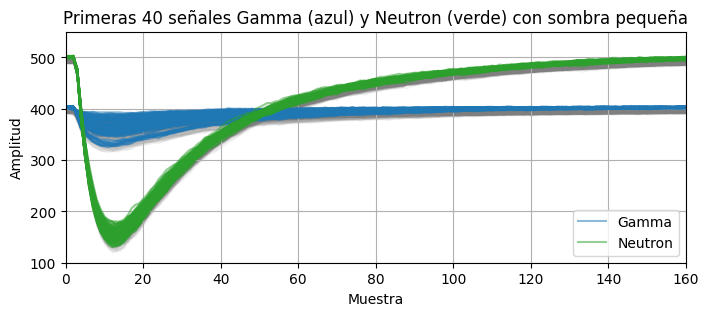

In [6]:
# Explore datasets and plot some signals
print("Gamma dataset shape: ", newGamma.shape)
print("Neutron dataset shape: ", newNeutron.shape)

plt.figure(figsize=(8, 3))

# Graficar 40 señales gamma en azul con sombra pequeña debajo de la línea
for i in range(100):
    y = newGamma[i, :]
    x = range(len(y))
    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

# Graficar 40 señales neutron en verde con sombra pequeña debajo de la línea
for i in range(100):
    y = newNeutron[i, :]
    x = range(len(y))
    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.title("Primeras 40 señales Gamma (azul) y Neutron (verde) con sombra pequeña")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.xlim(0, 160)
plt.ylim(100, 550)
plt.legend()
plt.grid()
plt.show()

# Calculo de energia y FIC en dataset reducido

In [7]:
def compute_energy_fci(pulses):

    n_events, n_samples = pulses.shape

    energy = np.zeros(n_events)
    fci = np.zeros(n_events)

    for i in range(n_events):

        pulse = pulses[i]

        # baseline (primeras muestras)
        baseline = pulse[:5].mean()

        # convertir pulso negativo a positivo
        signal = baseline - pulse
        signal[signal < 0] = 0

        # energía total
        total = signal.sum()

        # localizar pico
        peak = np.argmax(signal)

        # ventana rápida
        fast_window = 8
        fast_end = min(peak + fast_window, n_samples)

        fast = signal[peak:fast_end].sum()

        energy[i] = total
        fci[i] = fast / total if total > 0 else 0

    return energy, fci


In [8]:
# calcular para ambos datasets
energy_neutron, fci_neutron = compute_energy_fci(newNeutron)
energy_gamma, fci_gamma = compute_energy_fci(newGamma)

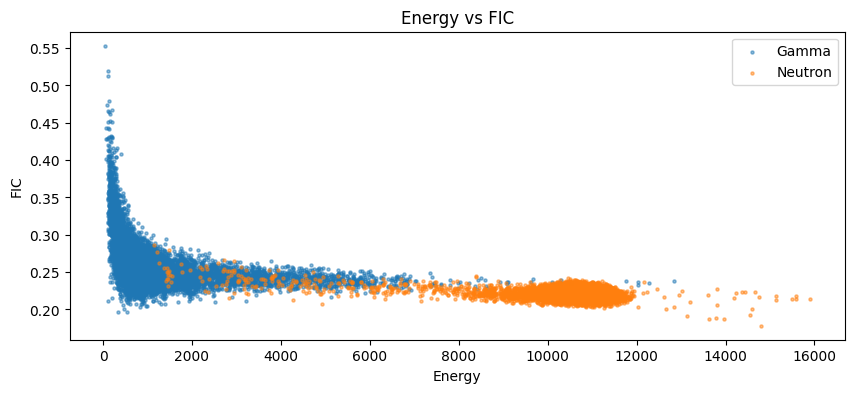

In [9]:
# graficar
plt.figure(figsize=(10, 4))

plt.scatter(energy_gamma, fci_gamma, s=5, alpha=0.5, label="Gamma")
plt.scatter(energy_neutron, fci_neutron, s=5, alpha=0.5, label="Neutron")

plt.xlabel("Energy")
plt.ylabel("FIC")
plt.title("Energy vs FIC")

plt.legend()
plt.show()

In [10]:
def compute_energy_psd(pulses):

    n_events, n_samples = pulses.shape

    energy = np.zeros(n_events)
    psd = np.zeros(n_events)

    for i in range(n_events):

        pulse = pulses[i]

        baseline = pulse[:5].mean()

        signal = baseline - pulse
        signal[signal < 0] = 0

        total = signal.sum()

        peak = np.argmax(signal)

        # inicio de la cola
        tail_start = peak + 5

        tail = signal[tail_start:].sum()

        energy[i] = total
        psd[i] = tail / total if total > 0 else 0

    return energy, psd

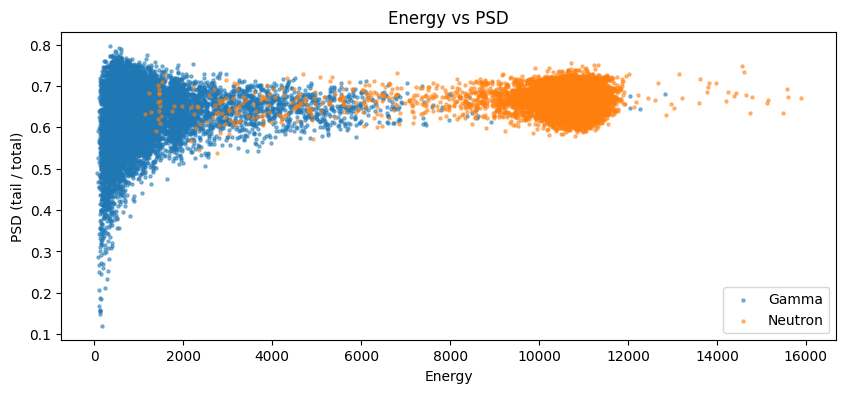

In [11]:
energy_neutron, psd_neutron = compute_energy_psd(newNeutron)
energy_gamma, psd_gamma = compute_energy_psd(newGamma)


plt.figure(figsize=(10, 4))

plt.scatter(energy_gamma, psd_gamma, s=5, alpha=0.5, label="Gamma")
plt.scatter(energy_neutron, psd_neutron, s=5, alpha=0.5, label="Neutron")

plt.xlabel("Energy")
plt.ylabel("PSD (tail / total)")
plt.title("Energy vs PSD")

plt.legend()
plt.show()

In [12]:
# Convertir a DataFrame
df_neutron = pd.DataFrame(newNeutron)
df_gamma = pd.DataFrame(newGamma)

# Agregar columna de clase
df_neutron["class"] = 1
df_gamma["class"] = 0

n_samples = 1000

# Seleccionar test
test_neutron = df_neutron.sample(n=n_samples, random_state=45)
test_gamma = df_gamma.sample(n=n_samples, random_state=45)

# Crear train eliminando esas filas
train_neutron = df_neutron.drop(test_neutron.index)
train_gamma = df_gamma.drop(test_gamma.index)

# Construir datasets finales
test_df = pd.concat([test_neutron, test_gamma], axis=0)
train_df = pd.concat([train_neutron, train_gamma], axis=0)

# Mezclar filas
#test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
#train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Guardar CSV
test_df.to_csv("dataset/test_dataset.csv", index=False)
train_df.to_csv("dataset/train_dataset.csv", index=False)
train_gamma.to_csv("dataset/train_gamma_dataset.csv", index=False)
train_neutron.to_csv("dataset/train_neutron_dataset.csv", index=False)

Gamma dataset shape:  (9913, 162)
Neutron dataset shape:  (26696, 162)


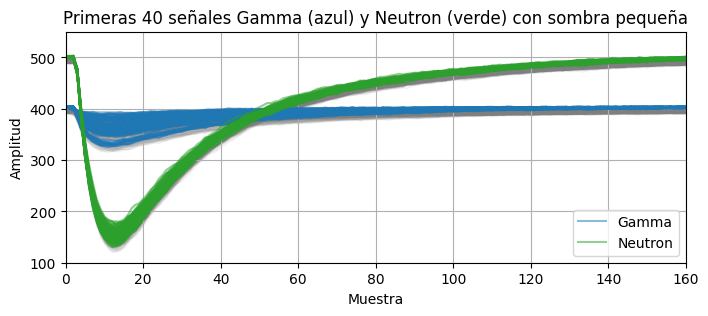

In [13]:
# Explore datasets and plot some signals
print("Gamma dataset shape: ", train_gamma.shape)
print("Neutron dataset shape: ", train_neutron.shape)

plt.figure(figsize=(8, 3))

# Graficar 40 señales gamma en azul con sombra pequeña debajo de la línea
for i in range(100):
    y = train_gamma.iloc[i, :-1]
    x = range(len(y))
    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

# Graficar 40 señales neutron en verde con sombra pequeña debajo de la línea
for i in range(100):
    y = train_neutron.iloc[i, :-1]
    x = range(len(y))
    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.title("Primeras 40 señales Gamma (azul) y Neutron (verde) con sombra pequeña")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.xlim(0, 160)
plt.ylim(100, 550)
plt.legend()
plt.grid()
plt.show()

Gamma dataset shape: (9913, 162)
Neutron dataset shape: (26696, 162)


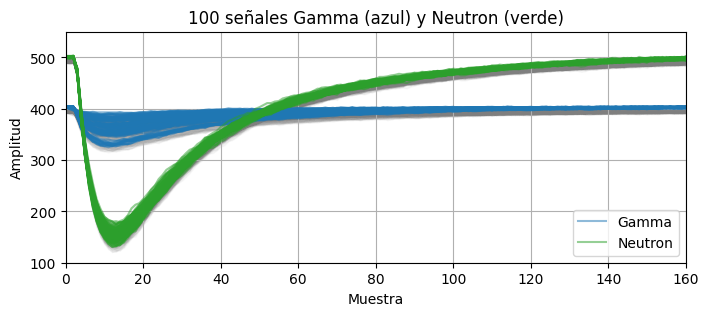

In [14]:
# separar clases
train_gamma_new = train_df[train_df["class"] == 0]
train_neutron_new = train_df[train_df["class"] == 1]

print("Gamma dataset shape:", train_gamma_new.shape)
print("Neutron dataset shape:", train_neutron_new.shape)

plt.figure(figsize=(8,3))

# gamma
for i in range(100):
    y = train_gamma_new.iloc[i, :-1]
    x = range(len(y))

    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)

# neutron
for i in range(100):
    y = train_neutron_new.iloc[i, :-1]
    x = range(len(y))

    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)

plt.title("100 señales Gamma (azul) y Neutron (verde)")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")

plt.xlim(0,160)
plt.ylim(100,550)

plt.legend()
plt.grid()
plt.show()